In [1]:
import os, argparse, typing
os.chdir("/home/wergillius/Project/PINN_dynamics")

import numpy as np
import pandas as pd
import torch 

from PINN import models as models
from PINN import reader 
from PINN import functions as fns

import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

import warnings; warnings.filterwarnings("ignore") # remove scanpy warnings for the tutorial.
import decipher as dc
import scvi

In [2]:
dc.pl.activate_journal_quality()

In [3]:
# load data
ery_mk_ad = sc.read_h5ad("data/ery_mk.h5ad")
pt_path = "data/HSPC_mk_ery.pt" 
D = torch.load(pt_path)

In [9]:
color_palette = None
ery_mk_ad.uns['color_palette'] = color_palette

# get the raw counts

In [28]:
erymk_raw = ery_mk_ad.raw.to_adata()

In [33]:
erymk_raw.layers['exp'] =  erymk_raw.X.expm1()

In [67]:
scale_factor = erymk_raw.obs['n_counts'].values / 10000
scale_factor = scale_factor.reshape(-1,1)

In [84]:
from scipy.sparse import hstack, vstack
Raw_counts = [erymk_raw.layers['exp'][i]* scale_factor[i].item() for i in range(scale_factor.shape[0])]
Raw_count_ay = vstack(Raw_counts)

erymk_raw.layers['Rawcount'] = Raw_count_ay.astype(int)
Raw_count_ay.shape

In [90]:
erymk_raw.layers['Rawcount'] = Raw_count_ay.astype(int)

In [101]:
ery_mk_ad.layers['Counts'] = erymk_raw[:,ery_mk_ad.var_names].layers['Rawcount'].copy()

In [102]:
ery_mk_ad.write_h5ad("data/ery_mk.h5ad")

In [13]:
raw_data = sc.read_h5ad("data/combined_filt.h5ad")

In [21]:
adata = raw_data.raw.to_adata()

In [26]:
adata

AnnData object with n_obs × n_vars = 130700 × 22035
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 

In [37]:
# Load the AnnData (available at https://github.com/azizilab/decipher_data/data_decipher_tutorial.h5ad)
decipher_ad = sc.read_h5ad(f"data/data_decipher_tutorial.h5ad")

In [42]:
decipher_ad.X.A[:10, :10]

array([[5., 2., 5., 0., 0., 0., 2., 0., 0., 0.],
       [2., 0., 4., 0., 0., 0., 0., 2., 0., 0.],
       [5., 1., 2., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 5., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 7., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 1., 1., 0., 0.],
       [0., 0., 0., 5., 0., 0., 2., 0., 0., 0.],
       [0., 0., 5., 0., 0., 0., 0., 0., 0., 0.],
       [0., 2., 5., 0., 0., 0., 0., 0., 1., 0.],
       [0., 1., 1., 0., 3., 0., 0., 3., 0., 0.]], dtype=float32)

# try decipher

In [4]:
decipher_config = dc.tl.DecipherConfig() # optional Decipher config

In [5]:
decipher_config

DecipherConfig(dim_z=10, dim_v=2, layers_v_to_z=(64,), layers_z_to_x=(), beta=0.1, seed=0, learning_rate=0.005, val_frac=0.1, batch_size=64, n_epochs=1000, early_stopping_patience=10, dim_genes=None, n_cells=None, prior='normal', _initialized_from_adata=False)

In [6]:
ery_mk_ad.layers['Normed_X']=ery_mk_ad.X.copy()

In [7]:
ery_mk_ad.X = ery_mk_ad.layers['Rawcount']

Epoch 34 (batch 319/319) | | train elbo: 881.99 (last epoch: 882.29) | val ll: 873.04:   3%|▎         | 34/1000 [03:19<1:34:32,  5.87s/it]2024-07-09 22:50:47,027 | INFO : Early stopping has been triggered.
2024-07-09 22:50:47,596 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2024-07-09 22:50:47,597 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2024-07-09 22:50:47,707 | INFO : Saving decipher model with run_id 2024-07-09-22-50-47-internal-scared-coherent.


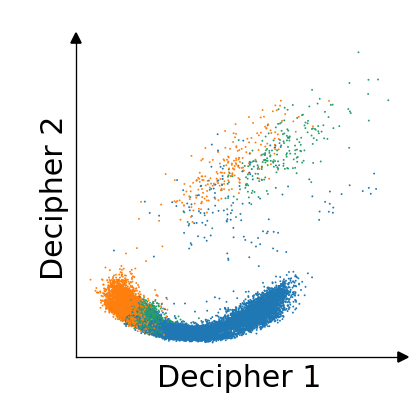

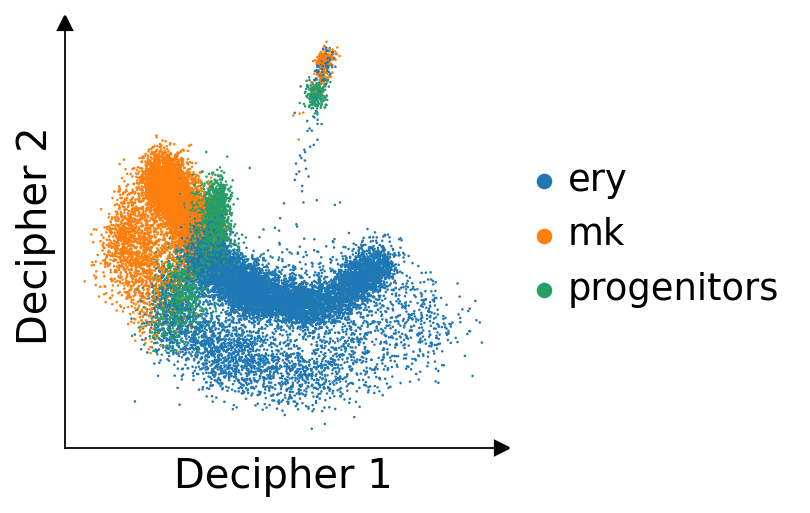

In [12]:
d1, val1 = dc.tl.decipher_train(
    ery_mk_ad, decipher_config, plot_kwargs={"color": "branch", "palette": color_palette}, 
    plot_every_k_epochs=20, device="cuda:2"
)

In [16]:
ery_mk_ad.write_h5ad("data/ery_mk.h5ad")

In [17]:
sc.pp.neighbors(ery_mk_ad, n_neighbors=50, use_rep='decipher_z')
sc.tl.umap(ery_mk_ad)

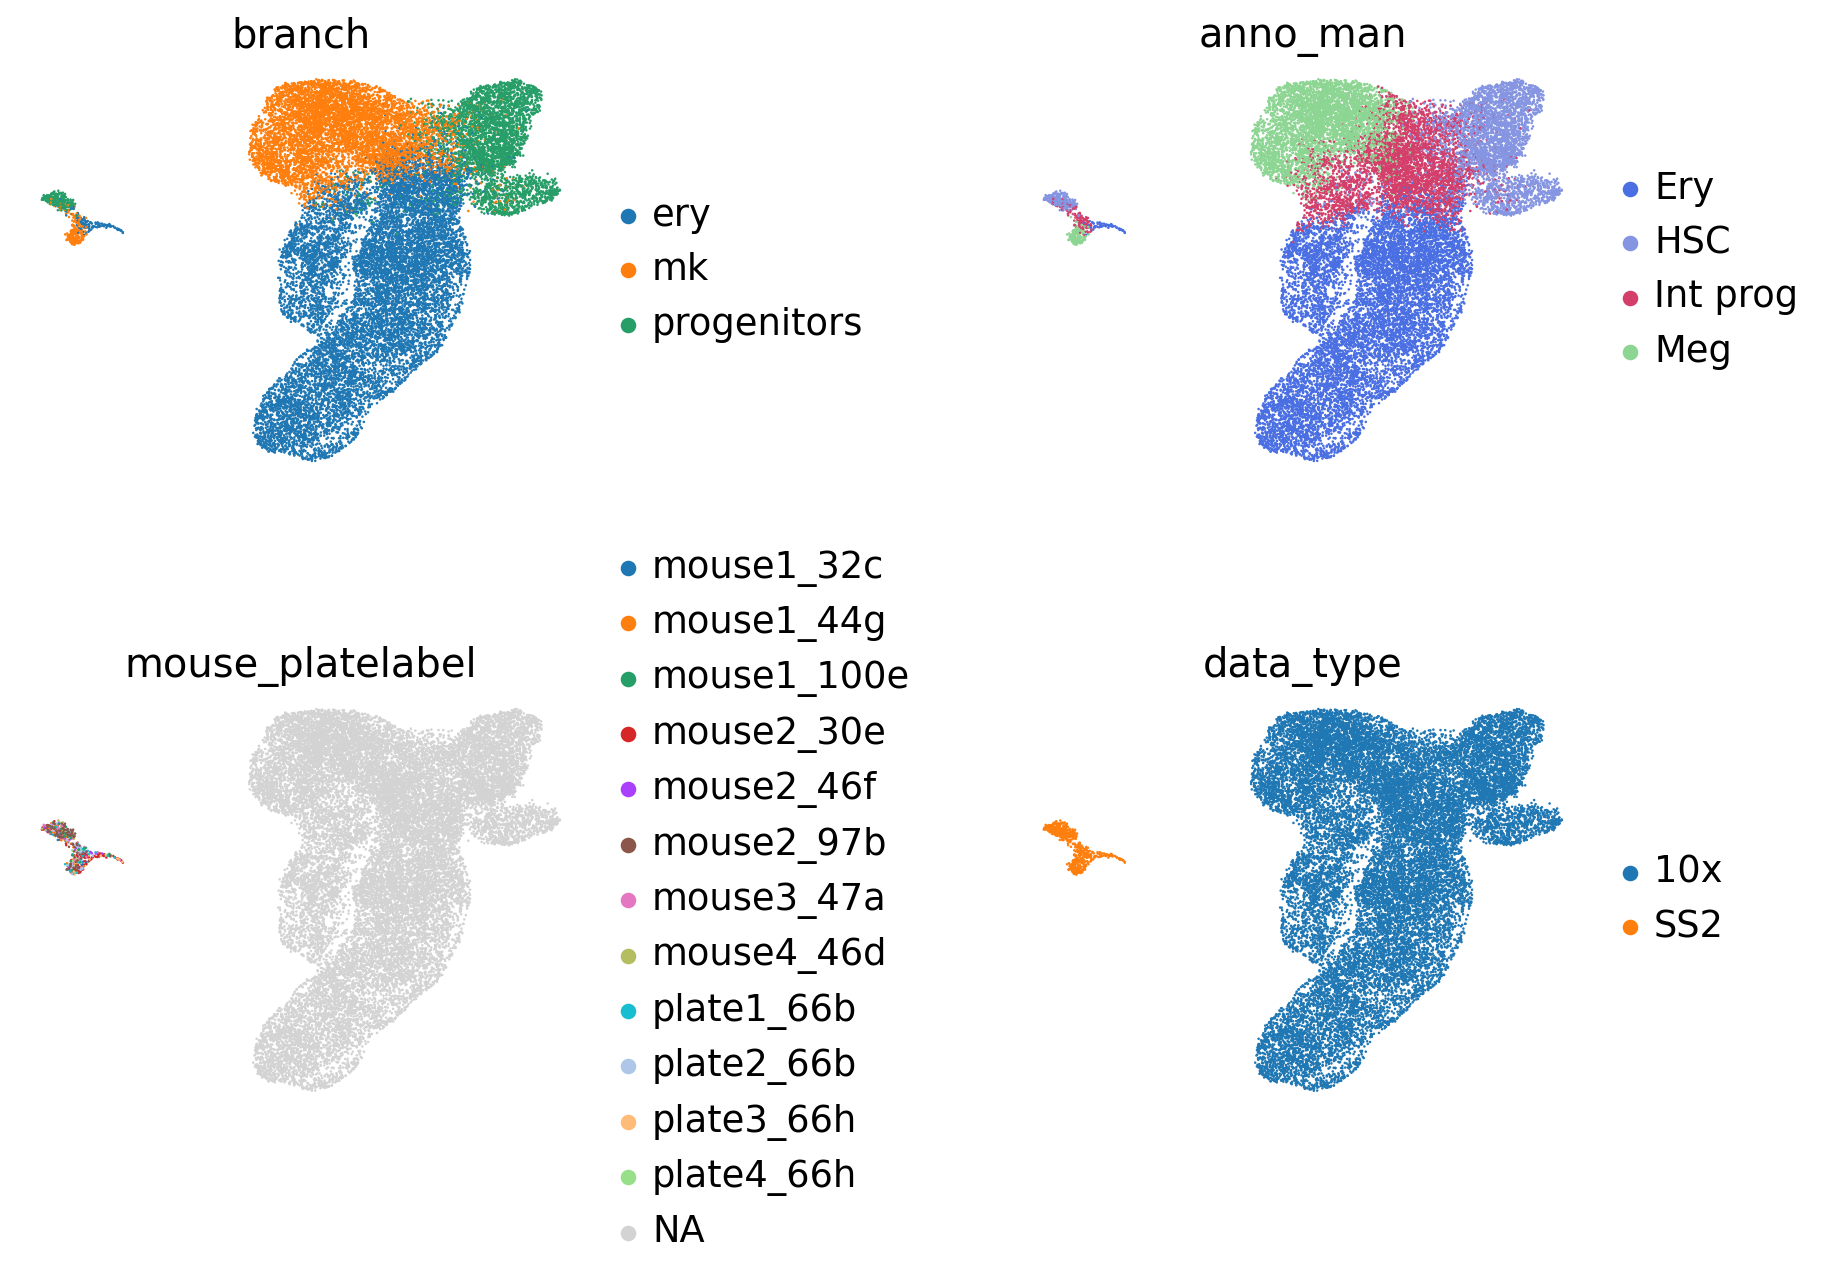

In [18]:
sc.pl.umap(ery_mk_ad, color=['branch', 'anno_man', 'mouse_platelabel', 'data_type'],
            frameon=False,
           ncols=2, hspace=0.5, wspace=0.6)

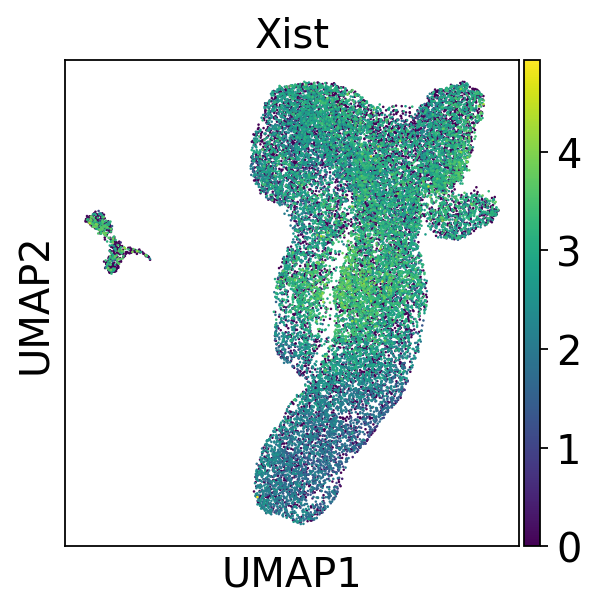

In [20]:
sc.pl.umap(ery_mk_ad, color= 'Xist')